|<img style="float:left;" src="../images/usherb_transp.gif" width=90% height=90%> |<big>Pierre Proulx, ing, professeur</big>|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|


### Reprise de la section 10B3 mais cylindrique


In [1]:
#
# Pierre Proulx
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline

In [2]:
# Paramètres, variables et fonctions
S_n,r,b,R_F,R_C,S_n0,delta_r,h,T_oo=sp.symbols('S_n,r,b,R_F,R_C,S_n0,delta_r,h,T_oo')                                                            
k_C,k_F=sp.symbols('k_C,k_F')             
q_F=sp.Function('q_F')(r)           # Notation de Transport Phenomena
T_F=sp.Function('T_F')(r) 
q_C=sp.Function('q_C')
T_C=sp.Function('T_C')(r)
S_n=S_n0*(1+b*(r/R_F)**2)

In [3]:
# La pose du bilan est semblable à 10-3
C1=sp.symbols('C1')
eq1=sp.Eq(r*q_F-sp.integrate(S_n*r,r)-C1,0) # ici je sépare et intègre moi-même, c'est direct
q_F=sp.solve(eq1,q_F)    # équation non-linéaire, sympy retourne une liste
q_F=q_F[0]

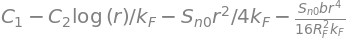

In [4]:
Fourier=-k_F*sp.diff(T_F,r)
eq2=sp.Eq(Fourier,q_F)
T_F=sp.dsolve(eq2,T_F)
T_F=T_F.rhs
#
# Attention à ceci: SYMPY change les noms des constantes d'intégration
# au fur et à mesure qu'il fait des intégrations, il renomme toujours en
# commençant C1 pour la dernière constante apparue. Nous ne faisons habituellement
# pas ça alors il faut changer nous-mêmes l'ordre des noms. C'est fait ci-dessous.
#
T_F=T_F.subs(sp.symbols('C2'),sp.symbols('C1t'))
T_F=T_F.subs(sp.symbols('C1'),sp.symbols('C2'))
T_F=T_F.subs(sp.symbols('C1t'),sp.symbols('C1'))
#
#
#
display(T_F)

'Température Uranium, solution générale'

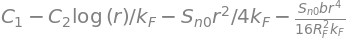

'Température Aluminium, solution générale'

'Flux Uranium, solution générale'

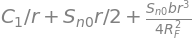

'Flux Aluminium, solution générale'

In [5]:
#
# Dans l'aluminium, la solution est plus simple évidemment car il n'y a pas de source
# On peut faire le travail à la main plus rapidement, on aura ainsi le flux défini:
# J'utilise les noms C3 et C4 pour les deux noms des constantes dans l'Aluminium
C3=sp.symbols('C3')
q_C=C3/r
Fourier=-k_C*sp.diff(T_C,r)
eq3=sp.Eq(Fourier,q_C)
T_C=sp.dsolve(eq3,T_C).subs('C1','C4')   # Il génère C1 par défaut
T_C=T_C.rhs
display('Température Uranium, solution générale',T_F)
display('Température Aluminium, solution générale',T_C)
display('Flux Uranium, solution générale',q_F)
display('Flux Aluminium, solution générale',q_C)

'Conditions aux limites'

'Constantes obtenues à partir des conditions aux limites'

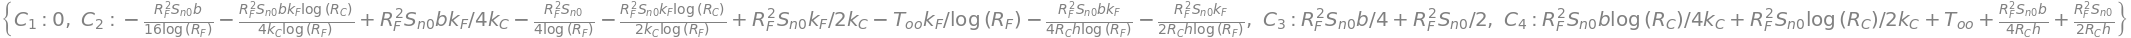

'Température Uranium '

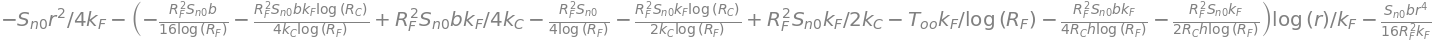

'Température Aluminium '

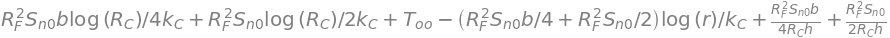

'flux Uranium '

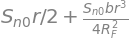

'flux Aluminium '

In [6]:
# Maintenant les conditions aux limites
condition_0=sp.Eq(q_F.subs(r,0),0)          # condition 0, pas de flux en r=0
condition_1=condition_4=sp.Eq(q_C.subs(r,R_F)-q_F.subs(r,R_F),0) # flux égaux
condition_2=sp.Eq(T_C.subs(r,R_F)-T_F.subs(r,R_F),0)  # Températures égales
condition_3=sp.Eq(h*(T_C.subs(r,R_C)-T_oo)-q_C.subs(r,R_C),0) # Température, surface extérieure
display('Conditions aux limites',condition_0,condition_1,condition_2,condition_3)
constantes=sp.solve([condition_0,condition_1,condition_2,condition_3],
                    sp.symbols('C1,C2,C3,C4'))
display('Constantes obtenues à partir des conditions aux limites',constantes)
T_C=T_C.subs(constantes)
T_F=T_F.subs(constantes)
q_C=q_C.subs(constantes)
q_F=q_F.subs(constantes)
display('Température Uranium ',T_F)
display('Température Aluminium ',T_C )
display('flux Uranium ',q_F )
display('flux Aluminium ',q_C )

<lambdifygenerated-1>:2: RuntimeWarning: divide by zero encountered in log
  return -284090909.090909*r**4 - 4545.45454545455*r**2 - 173.868038855407*log(r)
<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in scalar multiply
  return -284090909.090909*r**4 - 4545.45454545455*r**2 - 173.868038855407*log(r)


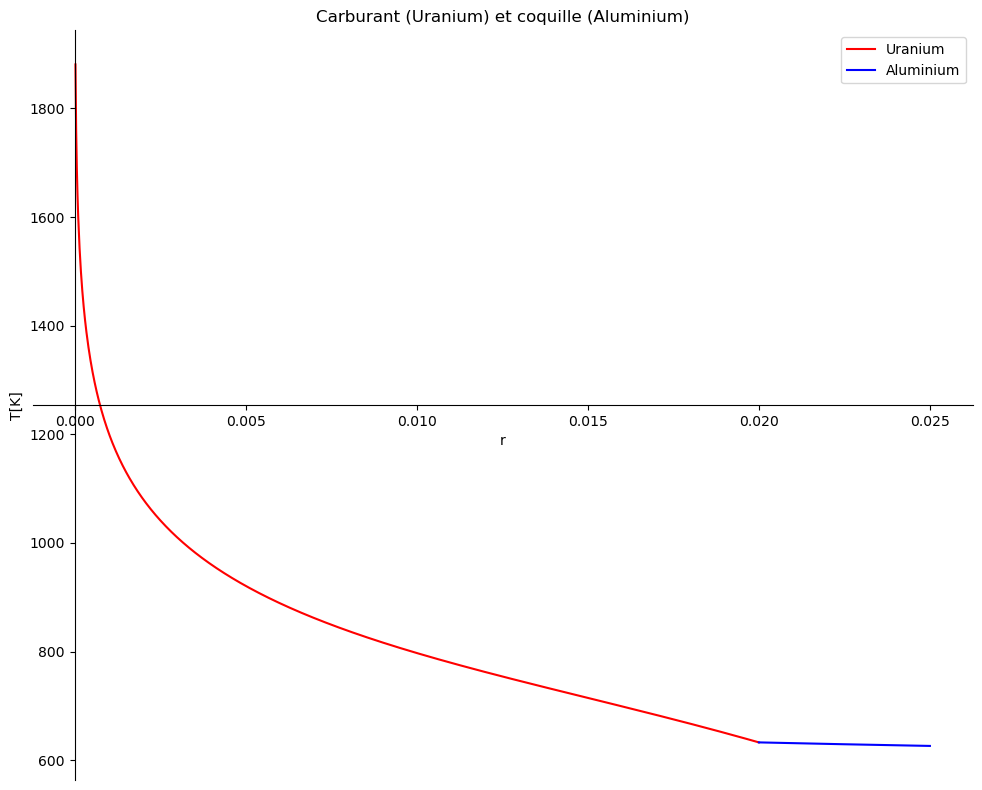

In [7]:
### Tracer un profil avec des valeurs physiques, on ajuste S_n0 pour avoir
### un maximum réaliste, après quelques essais. 
### Le profil devrait montrer les caractéristiques vues à la section 10.3
#
dico={'k_F':22,'k_C':140,'b':100,'R_F':0.02,'R_C':0.025,'S_n0':4e5,'T_oo':300,'h':500}
T_Fplot=T_F.subs(dico)
T_Cplot=T_C.subs(dico)
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=10,8
p = sp.plot((T_Fplot,(r,0,R_F.subs(dico))),(T_Cplot,(r,R_F.subs(dico),
                                                    R_C.subs(dico)))
            ,legend=True,xlabel='r',ylabel='T[K]'
            , title='Carburant (Uranium) et coquille (Aluminium)', show=False) 
p[0].line_color = 'red'
p[0].label='Uranium'
p[1].line_color = 'blue'
p[1].label='Aluminium'
p.show();